
# Member 1 — Dataset Understanding & Data Quality Analysis

## Objectives
- Understand dataset structure
- Inspect dataset quality
- Handle missing values
- Analyze duplicates


In [14]:
import pandas as pd

df = pd.read_excel(r"C:\Users\NIKHIL\Downloads\dataset -P676 (1).xlsx")

df.head()

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


## Dataset Inspection

In [15]:

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)


Dataset Shape: (1440, 3)

Columns:
Index(['title', 'rating', 'body'], dtype='object')

Data Types:
title     object
rating     int64
body      object
dtype: object


## Identified Important Columns

In [16]:

title_column = "title"
rating_column = "rating"
body_column = "body"

print("Title Column:", title_column)
print("Rating Column:", rating_column)
print("Body Column:", body_column)


Title Column: title
Rating Column: rating
Body Column: body


## Missing Value Analysis

In [17]:

missing_values = df.isnull().sum()
missing_values


title     0
rating    0
body      0
dtype: int64

## Handling Missing Values

In [18]:

# Remove rows with missing important review text
important_cols = [col for col in ["title", "rating", "body"] if col != "None"]

cleaned_df = df.dropna(subset=important_cols)

print("Original Shape:", df.shape)
print("After Removing Missing Values:", cleaned_df.shape)


Original Shape: (1440, 3)
After Removing Missing Values: (1440, 3)


## Duplicate Analysis

In [19]:

duplicate_rows = df.duplicated().sum()
print("Duplicate Rows:", duplicate_rows)

if "title" != "None":
    print("Duplicate Titles:", df["title"].duplicated().sum())

if "body" != "None":
    print("Duplicate Bodies:", df["body"].duplicated().sum())


Duplicate Rows: 0
Duplicate Titles: 89
Duplicate Bodies: 0


## Remove Duplicate Rows

In [20]:

df_no_duplicates = cleaned_df.drop_duplicates()

print("Shape Before Removing Duplicates:", cleaned_df.shape)
print("Shape After Removing Duplicates:", df_no_duplicates.shape)


Shape Before Removing Duplicates: (1440, 3)
Shape After Removing Duplicates: (1440, 3)


## Final Dataset Summary

In [21]:

print(df_no_duplicates.info())

df_no_duplicates.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB
None


,title,rating,body
count,1440,1440.000000,1440
unique,1351,NaN,1440
top,Value for money,NaN,Very disappointed with the overall performance...
freq,16,NaN,1
mean,NaN,3.173611,NaN
std,NaN,1.584453,NaN
min,NaN,1.000000,NaN
25%,NaN,1.000000,NaN
50%,NaN,4.000000,NaN
75%,NaN,5.000000,NaN


## Data Preprocessing

The text data in the 'title' and 'body' columns needs to be cleaned to ensure consistency and improve the performance of downstream natural language processing tasks. This includes converting text to lowercase, removing punctuation, digits, and extra whitespace.

In [22]:
import re
import string

def clean_text(text):
    text = str(text).lower()  # Convert to string and lowercase
    text = re.sub(r'(?<=\w)-(?=\w)', ' ', text) # Replace hyphens within words with space
    text = re.sub(r'@[^\s]+', ' ', text)  # Remove mentions
    text = re.sub(r'((www\.[^\s]+)|(https?://[^\s]+))', ' ', text)  # Remove URLs
    text = re.sub(r'[%s]' % re.escape(string.punctuation), ' ', text)  # Remove punctuation using string.punctuation
    text = re.sub(r'\s+', ' ', text)  # Remove extra spaces
    text = re.sub(r'\d+', '', text)  # Remove digits
    return text.strip()

# Apply text cleaning to 'title' and 'body' columns
df_processed = df_no_duplicates.copy()
df_processed['title_cleaned'] = df_processed['title'].apply(clean_text)
df_processed['body_cleaned'] = df_processed['body'].apply(clean_text)

display(df_processed[['title', 'title_cleaned', 'body', 'body_cleaned']].head())

,title,title_cleaned,body,body_cleaned
0,Horrible product,horrible product,Very disappointed with the overall performance...,very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,camera quality is not like megapixel,Camera quality is low,camera quality is low
2,Overall,overall,"Got the mobile on the launch date,Battery must...",got the mobile on the launch date battery must...
3,A big no from me,a big no from me,1. It doesn't work with 5.0GHz WiFi frequency....,it doesn t work with ghz wifi frequency ghz ...
4,Put your money somewhere else,put your money somewhere else,"Not worth buying....faulty software, poor disp...",not worth buying faulty software poor display ...


### Tokenization

Tokenization is the process of breaking a stream of text into words, phrases, symbols, or other meaningful elements called tokens. These tokens are then used as input for further processing.

In [23]:
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab') # Download 'punkt_tab' resource

# Apply tokenization to cleaned text
df_processed['title_tokens'] = df_processed['title_cleaned'].apply(word_tokenize)
df_processed['body_tokens'] = df_processed['body_cleaned'].apply(word_tokenize)

display(df_processed[['title_cleaned', 'title_tokens', 'body_cleaned', 'body_tokens']].head())

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\NIKHIL\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\NIKHIL\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


,title_cleaned,title_tokens,body_cleaned,body_tokens
0,horrible product,"[horrible, product]",very disappointed with the overall performance...,"[very, disappointed, with, the, overall, perfo..."
1,camera quality is not like megapixel,"[camera, quality, is, not, like, megapixel]",camera quality is low,"[camera, quality, is, low]"
2,overall,[overall],got the mobile on the launch date battery must...,"[got, the, mobile, on, the, launch, date, batt..."
3,a big no from me,"[a, big, no, from, me]",it doesn t work with ghz wifi frequency ghz ...,"[it, doesn, t, work, with, ghz, wifi, frequenc..."
4,put your money somewhere else,"[put, your, money, somewhere, else]",not worth buying faulty software poor display ...,"[not, worth, buying, faulty, software, poor, d..."


### Removing Stop Words

Stop words are common words (like 'the', 'is', 'and') that often carry little meaning in text analysis and can be removed to reduce noise and improve processing efficiency. We will use NLTK's list of English stop words.

In [24]:
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

# Apply stop word removal to tokenized text
df_processed['title_tokens_cleaned'] = df_processed['title_tokens'].apply(remove_stopwords)
df_processed['body_tokens_cleaned'] = df_processed['body_tokens'].apply(remove_stopwords)

display(df_processed[['title_tokens', 'title_tokens_cleaned', 'body_tokens', 'body_tokens_cleaned']].head())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\NIKHIL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,title_tokens,title_tokens_cleaned,body_tokens,body_tokens_cleaned
0,"[horrible, product]","[horrible, product]","[very, disappointed, with, the, overall, perfo...","[disappointed, overall, performance, samsung]"
1,"[camera, quality, is, not, like, megapixel]","[camera, quality, like, megapixel]","[camera, quality, is, low]","[camera, quality, low]"
2,[overall],[overall],"[got, the, mobile, on, the, launch, date, batt...","[got, mobile, launch, date, battery, must, app..."
3,"[a, big, no, from, me]",[big],"[it, doesn, t, work, with, ghz, wifi, frequenc...","[work, ghz, wifi, frequency, ghz, old, school,..."
4,"[put, your, money, somewhere, else]","[put, money, somewhere, else]","[not, worth, buying, faulty, software, poor, d...","[worth, buying, faulty, software, poor, displa..."


### Lemmatization

Lemmatization is the process of grouping together the inflected forms of a word so they can be analyzed as a single item, identified by the word's lemma or dictionary form. For example, 'running', 'runs', and 'ran' would all be lemmatized to 'run'. This helps reduce the sparsity of the data and improves the efficiency and accuracy of text analysis tasks.

In [25]:
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

# Apply lemmatization to the cleaned tokens
df_processed['title_tokens_lemmatized'] = df_processed['title_tokens_cleaned'].apply(lemmatize_tokens)
df_processed['body_tokens_lemmatized'] = df_processed['body_tokens_cleaned'].apply(lemmatize_tokens)

display(df_processed[['title_tokens_cleaned', 'title_tokens_lemmatized', 'body_tokens_cleaned', 'body_tokens_lemmatized']].head())

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\NIKHIL\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\NIKHIL\AppData\Roaming\nltk_data...


,title_tokens_cleaned,title_tokens_lemmatized,body_tokens_cleaned,body_tokens_lemmatized
0,"[horrible, product]","[horrible, product]","[disappointed, overall, performance, samsung]","[disappointed, overall, performance, samsung]"
1,"[camera, quality, like, megapixel]","[camera, quality, like, megapixel]","[camera, quality, low]","[camera, quality, low]"
2,[overall],[overall],"[got, mobile, launch, date, battery, must, app...","[got, mobile, launch, date, battery, must, app..."
3,[big],[big],"[work, ghz, wifi, frequency, ghz, old, school,...","[work, ghz, wifi, frequency, ghz, old, school,..."
4,"[put, money, somewhere, else]","[put, money, somewhere, else]","[worth, buying, faulty, software, poor, displa...","[worth, buying, faulty, software, poor, displa..."


In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Join the lemmatized tokens back into strings for TF-IDF Vectorization
df_processed['title_text_lemmatized'] = df_processed['title_tokens_lemmatized'].apply(lambda x: ' '.join(x))
df_processed['body_text_lemmatized'] = df_processed['body_tokens_lemmatized'].apply(lambda x: ' '.join(x))

# Initialize TF-IDF Vectorizers
tfidf_vectorizer_title = TfidfVectorizer(max_features=5000) # Limiting to 5000 features for titles
tfidf_vectorizer_body = TfidfVectorizer(max_features=10000) # Limiting to 10000 features for body

# Fit and transform the title text
tfidf_features_title = tfidf_vectorizer_title.fit_transform(df_processed['title_text_lemmatized'])

# Fit and transform the body text
tfidf_features_body = tfidf_vectorizer_body.fit_transform(df_processed['body_text_lemmatized'])

print("Shape of TF-IDF features for titles:", tfidf_features_title.shape)
print("Shape of TF-IDF features for body:", tfidf_features_body.shape)

# Display a sample of the feature names for titles
print("\nSample TF-IDF feature names (titles):")
print(tfidf_vectorizer_title.get_feature_names_out()[:20])

# Display a sample of the feature names for body
print("\nSample TF-IDF feature names (body):")
print(tfidf_vectorizer_body.get_feature_names_out()[:20])

Shape of TF-IDF features for titles: (1440, 1022)
Shape of TF-IDF features for body: (1440, 4877)

Sample TF-IDF feature names (titles):
['able' 'absolute' 'absolutely' 'accepting' 'acchi' 'according' 'achcha'
 'achchaa' 'actual' 'ad' 'added' 'addicted' 'additional' 'addl' 'adequate'
 'advertised' 'advertising' 'adware' 'affordable' 'age']

Sample TF-IDF feature names (body):
['aanel' 'aap' 'aaya' 'ab' 'abhi' 'abide' 'ability' 'able' 'abruptly'
 'absence' 'absentresolution' 'absolute' 'absolutely' 'abt' 'accept'
 'acceptable' 'acceptance' 'accepted' 'accepting' 'accepts']


In [27]:
from scipy.sparse import hstack

# Function to map ratings to sentiment labels
def get_sentiment(rating):
    if rating >= 4:
        return 'positive'
    elif rating == 3:
        return 'neutral'
    else:
        return 'negative'

# Apply the function to create a new 'sentiment' column
df_processed['sentiment'] = df_processed['rating'].apply(get_sentiment)

# Combine TF-IDF features for title and body
X = hstack([tfidf_features_title, tfidf_features_body])

# The target variable 'sentiment' is now created
y = df_processed['sentiment']

print("Shape of combined features (X):", X.shape)
print("Shape of target variable (y):", y.shape)
print("\nSample of target variable (y):")
print(y.head())

Shape of combined features (X): (1440, 5899)
Shape of target variable (y): (1440,)

Sample of target variable (y):
0    negative
1     neutral
2    positive
3    negative
4    negative
Name: sentiment, dtype: object


In [30]:
!pip install --upgrade pip setuptools wheel

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.5/1.8 MB 2.4 MB/s eta 0:00:01
   ----------------- ---------------------- 0.8/1.8 MB 1.5 MB/s eta 0:00:01
   ---------------------------- ----------- 1.3/1.8 MB 1.5 MB/s eta 0:00:01
   ---------------------------------- ----- 1.6/1.8 MB 1.5 MB/s eta 0:00:01
   ---------------------------------- ----- 1.6/1.8 MB 1.5 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 1.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.3/1.0 MB ? eta -:--:--
   -------------------- ------------------- 0.5/1.0 MB 932.9 kB/s eta 0:00:01
   ------------------------------- --------

ERROR: To modify pip, please run the following command:
C:\ProgramData\anaconda3\python.exe -m pip install --upgrade pip setuptools wheel


In [31]:
!pip install langdetect

Defaulting to user installation because normal site-packages is not writeable
  Using cached langdetect-1.0.9.tar.gz (981 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993251 sha256=0268ee1d09c3f3269d5af52ccc5e53886bddf576f25e4ce9a4498311b7023da4
  Stored in directory: c:\users\nikhil\appdata\local\pip\cache\wheels\c1\67\88\e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [61]:
import pandas as pd
import matplotlib.pyplot as plt
from langdetect import detect

# Create Language Detection Function

In [62]:
def detect_language(text):

    try:
        return detect(str(text))

    except:
        return "unknown"

# Apply Language Detection

In [63]:
df_processed['language'] = df_processed['body_cleaned'].apply(
    detect_language
)

# Check Output

In [64]:
df_processed[['body_cleaned', 'language']].head(10)

,body_cleaned,language
0,very disappointed with the overall performance...,en
1,camera quality is low,en
2,got the mobile on the launch date battery must...,en
3,it doesn t work with ghz wifi frequency ghz ...,en
4,not worth buying faulty software poor display ...,en
5,i will never purchase samsung phones phone is ...,en
6,this is worst samsung mobile i have seen from ...,en
7,मोबाइल का कैमरा बिल्कुल भी सही नही है pm बताय...,hi
8,the phone hangs a lot and is very slow i recei...,en
9,very poor quality camera found box seal damage...,en


# Convert Language Codes

In [46]:
language_map = {
    "en": "English",
    "hi": "Hindi",
    "ta": "Tamil",
    "te": "Telugu"
}

df_processed["language"] = (
    df_processed["language"]
    .map(language_map)
    .fillna("Other")
)

In [47]:
df_processed[['body_cleaned', 'language']].head(10)

,body_cleaned,language
0,very disappointed with the overall performance...,Other
1,camera quality is low,Other
2,got the mobile on the launch date battery must...,Other
3,it doesn t work with ghz wifi frequency ghz ...,Other
4,not worth buying faulty software poor display ...,Other
5,i will never purchase samsung phones phone is ...,Other
6,this is worst samsung mobile i have seen from ...,Other
7,मोबाइल का कैमरा बिल्कुल भी सही नही है pm बताय...,Other
8,the phone hangs a lot and is very slow i recei...,Other
9,very poor quality camera found box seal damage...,Other


# Language Distribution Analysis

In [56]:
from langdetect import detect

def detect_language(text):

    try:
        return detect(str(text))

    except:
        return "unknown"

df_processed['language'] = df_processed['body'].apply(
    detect_language
)

In [59]:
language_percentage = (
    df_processed['language']
    .value_counts(normalize=True) * 100
)

print(language_percentage)

language
en    97.430556
hi     0.763889
id     0.416667
ca     0.208333
fr     0.208333
it     0.138889
no     0.138889
et     0.138889
af     0.069444
lv     0.069444
ml     0.069444
sk     0.069444
pl     0.069444
so     0.069444
nl     0.069444
ro     0.069444
Name: proportion, dtype: float64


In [60]:
print(
    df_processed['language'].unique()
)

['en' 'hi' 'af' 'ca' 'fr' 'it' 'id' 'lv' 'no' 'ml' 'sk' 'et' 'pl' 'so'
 'nl' 'ro']


## Check language counts



In [65]:
print(df_processed['language'].value_counts())

language
en    1405
hi      11
id       6
et       3
da       3
it       2
fr       2
af       1
lv       1
ml       1
sw       1
pl       1
so       1
nl       1
ro       1
Name: count, dtype: int64


## DOMINANT LANGUAGE

In [67]:
dominant_language = (
    df_processed['language']
    .mode()[0]
)

print("\nDominant Language:")
print(dominant_language)




Dominant Language:
en


## LANGUAGE DISTRIBUTION
### CHART


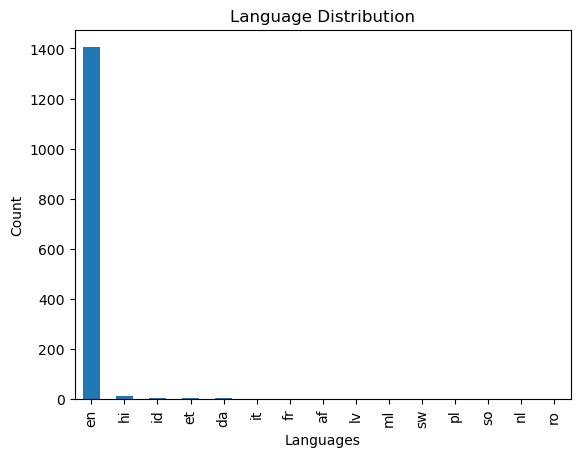

In [68]:
df_processed['language'].value_counts().plot(
    kind='bar'
)

plt.title("Language Distribution")
plt.xlabel("Languages")
plt.ylabel("Count")

plt.show()

## MIXED LANGUAGE
### DETECTION


In [69]:
def detect_mixed_language(text):

    text = str(text)

    has_english = any(
        ord(char) < 128 for char in text
    )

    has_telugu = any(
        '\u0C00' <= char <= '\u0C7F'
        for char in text
    )

    has_tamil = any(
        '\u0B80' <= char <= '\u0BFF'
        for char in text
    )

    if has_english and (
        has_telugu or has_tamil
    ):
        return "Mixed"

    return "Single"


df_processed['mixed_language'] = (
    df_processed['body']
    .apply(detect_mixed_language)
)

print("\nMixed Language Statistics:")
print(
    df_processed['mixed_language']
    .value_counts()
)




Mixed Language Statistics:
mixed_language
Single    1440
Name: count, dtype: int64


 ## TRANSLITERATION
### DETECTION

In [70]:
transliterated_words = [
    'bahut',
    'accha',
    'mast',
    'undi',
    'bagundi',
    'acha'
]


def transliteration_detection(text):

    text = str(text).lower()

    for word in transliterated_words:

        if word in text:
            return "Yes"

    return "No"


df_processed['transliteration'] = (
    df_processed['body']
    .apply(transliteration_detection)
)

print("\nTransliteration Statistics:")
print(
    df_processed['transliteration']
    .value_counts()
)


Transliteration Statistics:
transliteration
No     1432
Yes       8
Name: count, dtype: int64


##  OUTPUT

In [71]:
print(
    df_processed[
        [
            'body',
            'language',
            'mixed_language',
            'transliteration'
        ]
    ].head(10)
)


                                                body language mixed_language  \
0  Very disappointed with the overall performance...       en         Single   
1                              Camera quality is low       en         Single   
2  Got the mobile on the launch date,Battery must...       en         Single   
3  1. It doesn't work with 5.0GHz WiFi frequency....       en         Single   
4  Not worth buying....faulty software, poor disp...       en         Single   
5  I will never purchase Samsung phones. Phone is...       en         Single   
6  This is worst samsung mobile I have seen from ...       en         Single   
7  मोबाइल का कैमरा बिल्कुल भी सही नही है 48 PM बत...       hi         Single   
8  The phone hangs a lot and is very slow. I rece...       en         Single   
9  Very poor quality camera .Found box seal damag...       en         Single   

  transliteration  
0              No  
1              No  
2              No  
3              No  
4              No  

## FINAL REPORT

In [72]:
df_processed.to_csv(
    "language_analysis_report.csv",
    index=False
)

print("\nFinal Report Saved Successfully")


Final Report Saved Successfully
